# Notebook 5 — Training
Complete optimized nnU-Net training pipeline

In [1]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import random
import time
import json
import psutil
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS — edit here
# ============================================================
preprocessed_path  = 'preprocessed'
save_dir_imgs      = os.path.join(preprocessed_path, 'imagesTr')
save_dir_lbls      = os.path.join(preprocessed_path, 'labelsTr')
checkpoint_dir     = 'checkpoints'
log_dir            = 'training_logs'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

PATCH_SIZE         = (128, 128, 128)
PATCHES_PER_VOL    = 2      # patches per volume for training
BATCH_SIZE         = 2
NUM_EPOCHS         = 100
LR                 = 1e-4
WEIGHT_DECAY       = 1e-5
NUM_WORKERS        = 0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(42)

print(f'Device         : {device}')
print(f'GPU            : {torch.cuda.get_device_name(0)}')
print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'RAM available  : {psutil.virtual_memory().available/1024**3:.1f} GB')
print(f'PyTorch        : {torch.__version__}')

Device         : cuda
GPU            : NVIDIA GeForce RTX 4060
VRAM           : 8.0 GB
RAM available  : 7.7 GB
PyTorch        : 2.1.0+cu121


## Model Architecture

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.down = nn.Conv3d(out_ch, out_ch, 2, stride=2, bias=False)
    def forward(self, x):
        skip = self.conv(x)
        return self.down(skip), skip

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose3d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class nnUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=2, features=[32,64,128,256,320]):
        super().__init__()
        self.enc1       = EncoderBlock(in_ch,        features[0])
        self.enc2       = EncoderBlock(features[0],  features[1])
        self.enc3       = EncoderBlock(features[1],  features[2])
        self.enc4       = EncoderBlock(features[2],  features[3])
        self.enc5       = EncoderBlock(features[3],  features[4])
        self.bottleneck = ConvBlock(features[4], features[4])
        self.dec5       = DecoderBlock(features[4], features[4], features[3])
        self.dec4       = DecoderBlock(features[3], features[3], features[2])
        self.dec3       = DecoderBlock(features[2], features[2], features[1])
        self.dec2       = DecoderBlock(features[1], features[1], features[0])
        self.dec1       = DecoderBlock(features[0], features[0], features[0])
        self.out_conv   = nn.Conv3d(features[0], out_ch, 1)
        self.ds4        = nn.Conv3d(features[3], out_ch, 1)
        self.ds3        = nn.Conv3d(features[2], out_ch, 1)
        self.ds2        = nn.Conv3d(features[1], out_ch, 1)

    def forward(self, x):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        x4, s4 = self.enc4(x3)
        x5, s5 = self.enc5(x4)
        b       = self.bottleneck(x5)
        d5      = self.dec5(b,  s5)
        d4      = self.dec4(d5, s4)
        d3      = self.dec3(d4, s3)
        d2      = self.dec2(d3, s2)
        d1      = self.dec1(d2, s1)
        out     = self.out_conv(d1)
        if self.training:
            return out, self.ds4(d5), self.ds3(d4), self.ds2(d3)
        return out

print('Model defined ✅')

Model defined ✅


## Loss Functions

In [3]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred   = torch.softmax(pred, dim=1)[:, 1]
        target = target.squeeze(1)
        inter  = (pred * target).sum(dim=(1,2,3))
        union  = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - ((2*inter + self.smooth) / (union + self.smooth)).mean()

class DiceCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss()
    def forward(self, pred, target):
        return self.dice(pred, target) + self.ce(pred, target.squeeze(1).long())

class DeepSupervisionLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss    = DiceCELoss()
        self.weights = [0.5, 0.25, 0.15, 0.10]
    def forward(self, outputs, target):
        total = 0
        for w, out in zip(self.weights, outputs):
            t = F.interpolate(target, size=out.shape[2:], mode='nearest') if out.shape != target.shape else target
            total += w * self.loss(out, t)
        return total

print('Loss functions defined ✅')

Loss functions defined ✅


## Dataset — Patch Cache Strategy

In [4]:
def augment_patch(image, label):
    for ax in range(3):
        if random.random() > 0.5:
            image = np.flip(image, axis=ax).copy()
            label = np.flip(label, axis=ax).copy()
    k = random.randint(0, 3)
    if k > 0:
        image = np.rot90(image, k=k, axes=(0,1)).copy()
        label = np.rot90(label, k=k, axes=(0,1)).copy()
    if random.random() > 0.5:
        image = image * random.uniform(0.9, 1.1)
    if random.random() > 0.5:
        image = image + random.uniform(-0.1, 0.1)
    if random.random() > 0.5:
        image = image + np.random.normal(0, 0.05, image.shape).astype(np.float32)
    return image, label

def pad_volume(img, lbl, patch_size):
    for ax, p in enumerate(patch_size):
        if img.shape[ax] < p:
            pad        = [(0,0),(0,0),(0,0)]
            pad[ax]    = (0, p - img.shape[ax])
            img = np.pad(img, pad, mode='constant')
            lbl = np.pad(lbl, pad, mode='constant')
    return img, lbl

def extract_patch_cache(image_files, label_files,
                        img_dir, lbl_dir,
                        patch_size=(128,128,128),
                        patches_per_volume=2):
    px, py, pz     = patch_size
    cached_imgs    = []
    cached_lbls    = []

    for fname_img, fname_lbl in tqdm(zip(image_files, label_files),
                                      total=len(image_files),
                                      desc='Caching'):
        img = nib.load(os.path.join(img_dir, fname_img)).get_fdata().astype(np.float32)
        lbl = nib.load(os.path.join(lbl_dir, fname_lbl)).get_fdata().astype(np.float32)
        img, lbl = pad_volume(img, lbl, patch_size)

        tumor_coords = np.argwhere(lbl == 1)
        if len(tumor_coords) == 0:
            continue

        idxs = np.random.choice(len(tumor_coords),
                                 size=min(patches_per_volume, len(tumor_coords)),
                                 replace=False)
        for i in idxs:
            cx, cy, cz = tumor_coords[i]
            xs = int(np.clip(cx - px//2, 0, img.shape[0] - px))
            ys = int(np.clip(cy - py//2, 0, img.shape[1] - py))
            zs = int(np.clip(cz - pz//2, 0, img.shape[2] - pz))
            cached_imgs.append(img[xs:xs+px, ys:ys+py, zs:zs+pz].copy())
            cached_lbls.append(lbl[xs:xs+px, ys:ys+py, zs:zs+pz].copy())

    return cached_imgs, cached_lbls

class CachedDataset(Dataset):
    def __init__(self, cached_imgs, cached_lbls, augment=True):
        self.imgs    = cached_imgs
        self.lbls    = cached_lbls
        self.augment = augment

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.imgs[idx].copy()
        lbl = self.lbls[idx].copy()
        if self.augment:
            img, lbl = augment_patch(img, lbl)
        return torch.from_numpy(img).float().unsqueeze(0), \
               torch.from_numpy(lbl).float().unsqueeze(0)

print('Dataset classes defined ✅')

Dataset classes defined ✅


## Load and Cache Data

In [5]:
# File lists
all_images = sorted([f for f in os.listdir(save_dir_imgs) if f.endswith('.nii.gz') and not f.startswith('.')])
all_labels = sorted([f for f in os.listdir(save_dir_lbls) if f.endswith('.nii.gz') and not f.startswith('.')])

# Split
combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_imgs_s, all_lbls_s = zip(*combined)
train_imgs = list(all_imgs_s[:100])
train_lbls = list(all_lbls_s[:100])
val_imgs   = list(all_imgs_s[100:])
val_lbls   = list(all_lbls_s[100:])

print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')

# Cache patches
print('\nCaching training patches...')
train_cache_imgs, train_cache_lbls = extract_patch_cache(
    train_imgs, train_lbls, save_dir_imgs, save_dir_lbls,
    patch_size=PATCH_SIZE, patches_per_volume=PATCHES_PER_VOL
)

print('\nCaching validation patches...')
val_cache_imgs, val_cache_lbls = extract_patch_cache(
    val_imgs, val_lbls, save_dir_imgs, save_dir_lbls,
    patch_size=PATCH_SIZE, patches_per_volume=1
)

# Datasets
train_dataset = CachedDataset(train_cache_imgs, train_cache_lbls, augment=True)
val_dataset   = CachedDataset(val_cache_imgs,   val_cache_lbls,   augment=False)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

ram = psutil.virtual_memory()
print(f'\nTrain patches : {len(train_dataset)}')
print(f'Val patches   : {len(val_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'RAM used      : {ram.used/1024**3:.1f} GB / {ram.total/1024**3:.1f} GB')

Train: 100 | Val: 26

Caching training patches...


Caching: 100%|███████████████████████████████████████████████████████████████████████| 100/100 [04:15<00:00,  2.55s/it]



Caching validation patches...


Caching: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [01:07<00:00,  2.59s/it]


Train patches : 200
Val patches   : 26
Train batches : 100
Val batches   : 26
RAM used      : 11.2 GB / 15.6 GB


## Training Setup

In [18]:
# Model, optimizer, scheduler, loss
model     = nnUNet(in_ch=1, out_ch=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                        factor=0.5, patience=10, min_lr=1e-6)
criterion = DeepSupervisionLoss()
scaler    = GradScaler()   # mixed precision

def compute_dsc(pred, target, smooth=1e-5):
    pred   = (torch.softmax(pred, dim=1)[:, 1] > 0.5).float()
    target = target.squeeze(1)
    inter  = (pred * target).sum(dim=(1,2,3))
    union  = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + smooth) / (union + smooth)).mean().item()

total_params = sum(p.numel() for p in model.parameters())
print(f'Model params  : {total_params:,}')
print(f'Optimizer     : Adam lr={LR}')
print(f'Scheduler     : ReduceLROnPlateau')
print(f'Loss          : Dice + CE + Deep Supervision')
print(f'Mixed precision: enabled ✅')

Model params  : 24,705,704
Optimizer     : Adam lr=0.0001
Scheduler     : ReduceLROnPlateau
Loss          : Dice + CE + Deep Supervision
Mixed precision: enabled ✅


## Training Loop

In [19]:
num_epochs = 100

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0
    total_dsc  = 0
    for img, lbl in loader:
        img = img.to(device, non_blocking=True)
        lbl = lbl.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(img)
            loss    = criterion(outputs, lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            total_dsc  += compute_dsc(outputs[0], lbl)
        total_loss += loss.item()
    return total_loss / len(loader), total_dsc / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dsc  = 0
    with torch.no_grad():
        for img, lbl in loader:
            img  = img.to(device, non_blocking=True)
            lbl  = lbl.to(device, non_blocking=True)
            with autocast():
                out  = model(img)
                loss = criterion.loss(out, lbl)
            total_loss += loss.item()
            total_dsc  += compute_dsc(out, lbl)
    return total_loss / len(loader), total_dsc / len(loader)

# ============================================================
# MAIN TRAINING LOOP
# ============================================================
best_val_dsc = 0.0
history      = {'train_loss':[], 'val_loss':[], 'train_dsc':[], 'val_dsc':[], 'lr':[]}

print(f'Starting training for {NUM_EPOCHS} epochs...')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
print('=' * 70)

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_dsc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss,   val_dsc   = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    elapsed    = time.time() - start

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dsc'].append(train_dsc)
    history['val_dsc'].append(val_dsc)
    history['lr'].append(current_lr)

    print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
          f'| Train Loss: {train_loss:.4f} DSC: {train_dsc:.4f} '
          f'| Val Loss: {val_loss:.4f} DSC: {val_dsc:.4f} '
          f'| LR: {current_lr:.6f} '
          f'| Time: {elapsed:.0f}s')

    # Save best model only  ← no periodic checkpoints to save disk space
    if val_dsc > best_val_dsc:
        best_val_dsc = val_dsc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dsc'             : val_dsc,
            'val_loss'            : val_loss,
        }, os.path.join(checkpoint_dir, 'best_model.pth'))
        print(f'   ✅ Best model saved! Val DSC: {best_val_dsc:.4f}')

# Save history after full training
import json
os.makedirs(log_dir, exist_ok=True)
with open(os.path.join(log_dir, 'history.json'), 'w') as f:
    json.dump(history, f)
print("History saved!")
print('=' * 70)
print(f'Training complete! Best Val DSC: {best_val_dsc:.4f}')

Starting training for 100 epochs...
Train batches: 100 | Val batches: 26
Epoch [000/100] | Train Loss: 0.3311 DSC: 0.7357 | Val Loss: 0.5054 DSC: 0.5696 | LR: 0.000100 | Time: 57s
   ✅ Best model saved! Val DSC: 0.5696
Epoch [001/100] | Train Loss: 0.3148 DSC: 0.7488 | Val Loss: 0.5499 DSC: 0.5319 | LR: 0.000100 | Time: 57s
Epoch [002/100] | Train Loss: 0.3054 DSC: 0.7529 | Val Loss: 0.5466 DSC: 0.5415 | LR: 0.000100 | Time: 59s
Epoch [003/100] | Train Loss: 0.3046 DSC: 0.7591 | Val Loss: 0.5264 DSC: 0.5540 | LR: 0.000100 | Time: 57s
Epoch [004/100] | Train Loss: 0.3018 DSC: 0.7551 | Val Loss: 0.5189 DSC: 0.5552 | LR: 0.000100 | Time: 56s
Epoch [005/100] | Train Loss: 0.3044 DSC: 0.7548 | Val Loss: 0.4909 DSC: 0.5773 | LR: 0.000100 | Time: 58s
   ✅ Best model saved! Val DSC: 0.5773
Epoch [006/100] | Train Loss: 0.3012 DSC: 0.7548 | Val Loss: 0.5315 DSC: 0.5413 | LR: 0.000100 | Time: 58s
Epoch [007/100] | Train Loss: 0.3065 DSC: 0.7514 | Val Loss: 0.5416 DSC: 0.5369 | LR: 0.000100 | Tim

Epoch [075/100] | Train Loss: 0.1860 DSC: 0.8297 | Val Loss: 0.5186 DSC: 0.5534 | LR: 0.000003 | Time: 56s
Epoch [076/100] | Train Loss: 0.1779 DSC: 0.8324 | Val Loss: 0.5163 DSC: 0.5560 | LR: 0.000003 | Time: 57s
Epoch [077/100] | Train Loss: 0.1846 DSC: 0.8313 | Val Loss: 0.5208 DSC: 0.5530 | LR: 0.000002 | Time: 57s
Epoch [078/100] | Train Loss: 0.1822 DSC: 0.8313 | Val Loss: 0.5190 DSC: 0.5550 | LR: 0.000002 | Time: 56s
Epoch [079/100] | Train Loss: 0.1860 DSC: 0.8306 | Val Loss: 0.5189 DSC: 0.5550 | LR: 0.000002 | Time: 56s
Epoch [080/100] | Train Loss: 0.1880 DSC: 0.8307 | Val Loss: 0.5201 DSC: 0.5534 | LR: 0.000002 | Time: 56s
Epoch [081/100] | Train Loss: 0.1865 DSC: 0.8304 | Val Loss: 0.5193 DSC: 0.5545 | LR: 0.000002 | Time: 56s
Epoch [082/100] | Train Loss: 0.1849 DSC: 0.8295 | Val Loss: 0.5187 DSC: 0.5552 | LR: 0.000002 | Time: 56s
Epoch [083/100] | Train Loss: 0.1846 DSC: 0.8320 | Val Loss: 0.5210 DSC: 0.5530 | LR: 0.000002 | Time: 56s
Epoch [084/100] | Train Loss: 0.1855 

## Plot Training Curves

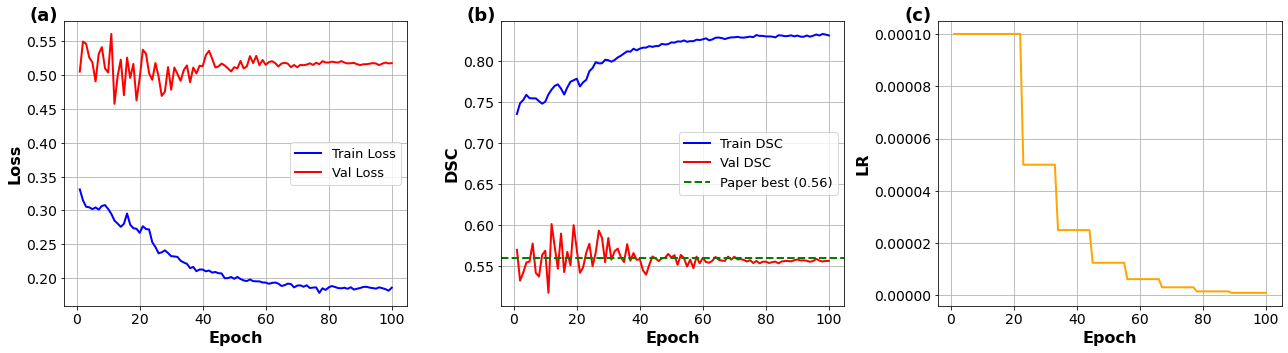

Saved → visualization_outputs/training_curves.png  (600 DPI PNG)

Final Results:
Best Val DSC  : 0.6011
Paper DSC     : 0.5600
Difference    : +0.0411


In [22]:
os.makedirs('visualization_outputs', exist_ok=True)
epochs = range(1, len(history['train_loss']) + 1)

# ── Font settings ──────────────────────────────────────────
LABEL_SIZE  = 16   # axis labels
TICK_SIZE   = 14   # tick labels
LEGEND_SIZE = 13   # legend text
PANEL_SIZE  = 18   # (a)(b)(c) labels
LINE_WIDTH  = 2.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel (a): Loss ────────────────────────────────────────
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue',  linewidth=LINE_WIDTH)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='red',   linewidth=LINE_WIDTH)
axes[0].set_xlabel('Epoch',  fontsize=LABEL_SIZE, fontweight='bold')
axes[0].set_ylabel('Loss',   fontsize=LABEL_SIZE, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=TICK_SIZE)
axes[0].legend(fontsize=LEGEND_SIZE)
axes[0].grid(True)
axes[0].text(-0.10, 1.05, '(a)', transform=axes[0].transAxes,
             fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')

# ── Panel (b): DSC ─────────────────────────────────────────
axes[1].plot(epochs, history['train_dsc'], label='Train DSC', color='blue', linewidth=LINE_WIDTH)
axes[1].plot(epochs, history['val_dsc'],   label='Val DSC',   color='red',  linewidth=LINE_WIDTH)
axes[1].axhline(y=0.56, color='green', linestyle='--', linewidth=LINE_WIDTH,
                label='Paper best (0.56)')
axes[1].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
axes[1].set_ylabel('DSC',   fontsize=LABEL_SIZE, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=TICK_SIZE)
axes[1].legend(fontsize=LEGEND_SIZE)
axes[1].grid(True)
axes[1].text(-0.10, 1.05, '(b)', transform=axes[1].transAxes,
             fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')

# ── Panel (c): Learning Rate ───────────────────────────────
axes[2].plot(epochs, history['lr'], color='orange', linewidth=LINE_WIDTH)
axes[2].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
axes[2].set_ylabel('LR',    fontsize=LABEL_SIZE, fontweight='bold')
axes[2].tick_params(axis='both', labelsize=TICK_SIZE)
axes[2].grid(True)
axes[2].text(-0.10, 1.05, '(c)', transform=axes[2].transAxes,
             fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')

# ── Save ───────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('visualization_outputs/training_curves.png',
            bbox_inches='tight', dpi=600, format='png')
plt.show()
print('Saved → visualization_outputs/training_curves.png  (600 DPI PNG)')

print(f'\nFinal Results:')
print(f'Best Val DSC  : {best_val_dsc:.4f}')
print(f'Paper DSC     : 0.5600')
print(f'Difference    : {best_val_dsc - 0.56:+.4f}')